# King County House Price Model

**Goal:** Build a hedonic pricing model to predict SFR sale prices in King County,  
quantifying the **marginal contribution** of each factor while controlling for all others.

**Why this matters over simple correlation:**  
- EDA showed school quality r = 0.77 with price — but top school districts also have bigger, newer homes  
- A model isolates: *holding house size and quality constant, how much is a better school district worth?*

**Sections**
1. Data loading & merging
2. Feature engineering
3. Predictor overview & rationale
4. Data quality & distributions
5. *(Modeling — next step)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

fmt_dol = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
ENC      = 'latin-1'
DATA_DIR = Path('kc_assessor_data')
EDU_DIR  = Path('education_data')
CRIME_DIR = Path('crime_data')

---
## 1. Data Loading & Merging

**Datasets joined:**

| Dataset | Source | Joined on |
|---------|--------|-----------|
| Real Property Sales | KC Assessor | base table |
| Residential Building | KC Assessor | PIN |
| Parcel | KC Assessor | PIN |
| School district lookup | GIS spatial join | PIN |
| OSPI school quality | WA OSPI | district name |
| Crime scores | SPD / BallTree | PIN (Seattle only) |

**Sale filter (same as EDA):** `SaleReason=1` + `PropertyClass=8` + `SalePrice > $10K`  
**Time window:** 2015–2024 (10 years — enough volume, recent enough to reflect current market)  
**Property type:** Single-family residential only (`NbrLivingUnits=1`)

In [2]:
# ── Load KC Assessor ──────────────────────────────────────────────────────────
print('Loading KC Assessor data...')
rp  = pd.read_csv(DATA_DIR/'RealPropertySales/EXTR_RPSale.csv',   low_memory=False, encoding=ENC)
rb  = pd.read_csv(DATA_DIR/'ResidentialBuilding/EXTR_ResBldg.csv', low_memory=False, encoding=ENC)
par = pd.read_csv(DATA_DIR/'Parcel/EXTR_Parcel.csv',               low_memory=False, encoding=ENC)
lu  = pd.read_csv(DATA_DIR/'Lookup/EXTR_LookUp.csv',               low_memory=False, encoding=ENC)

def make_pin(df):
    return df['Major'].astype(str).str.zfill(6) + df['Minor'].astype(str).str.zfill(4)

for df in [rp, rb, par]:
    df['PIN'] = make_pin(df)

rp['DocumentDate'] = pd.to_datetime(rp['DocumentDate'], errors='coerce')
rp['SaleYear']  = rp['DocumentDate'].dt.year
rp['SaleMonth'] = rp['DocumentDate'].dt.month

print(f'  RPSale:  {len(rp):,} rows')
print(f'  ResBldg: {len(rb):,} rows')
print(f'  Parcel:  {len(par):,} rows')

Loading KC Assessor data...


  RPSale:  2,415,964 rows
  ResBldg: 532,072 rows
  Parcel:  627,512 rows


In [3]:
# ── Arms-length SFR sales filter ──────────────────────────────────────────────
al = rp[
    (rp['SaleReason']    == 1) &
    (rp['SalePrice']      > 10_000) &
    (rp['PropertyClass'] == 8) &
    (rp['SaleYear'].between(2015, 2024))
].copy()

rb_sfr = rb[
    (rb['NbrLivingUnits'] == 1) &
    (rb['SqFtTotLiving'].between(200, 15_000)) &
    (rb['YrBuilt'].between(1870, 2024))
].sort_values('BldgNbr').drop_duplicates('PIN', keep='first')

par_u = par.drop_duplicates('PIN', keep='first')

# Keep all sales (not just latest per PIN) — each sale is an observation
sales = (
    al
    .merge(rb_sfr[['PIN','SqFtTotLiving','SqFtFinBasement','BldgGrade','Condition',
                   'YrBuilt','YrRenovated','Bedrooms','BathFullCount',
                   'Bath3qtrCount','BathHalfCount','NbrLivingUnits',
                   'ViewUtilization','Stories']], on='PIN', how='inner')
    .merge(par_u[['PIN','SqFtLot','WfntLocation','WfntFootage',
                  'MtRainier','Olympics','Cascades','Territorial',
                  'SeattleSkyline','PugetSound','LakeWashington',
                  'LakeSammamish','SmallLakeRiverCreek','OtherView',
                  'TrafficNoise','PowerLines','OtherNuisances']], on='PIN', how='left')
)

print(f'Arms-length SFR sales 2015–2024: {len(sales):,}')
print(f'Unique properties (PIN):          {sales["PIN"].nunique():,}')
print(f'Sale year range: {sales["SaleYear"].min()} – {sales["SaleYear"].max()}')

Arms-length SFR sales 2015–2024: 261,482
Unique properties (PIN):          206,094
Sale year range: 2015 – 2024


In [4]:
# ── Merge school quality ───────────────────────────────────────────────────────
print('Merging school quality...')
ospi = pd.read_csv(EDU_DIR/'ospi_assessment_2324_king.csv', low_memory=False)
ospi_clean = ospi[ospi['dat'].isna() | (ospi['dat']=='None') | (ospi['dat']=='')].copy()
ospi_clean['pct_met'] = pd.to_numeric(
    ospi_clean['percent_consistent_grade_level_knowledge_and_above'].astype(str).str.rstrip('%'),
    errors='coerce')
school_scores = (
    ospi_clean
    .pivot_table(index='districtname', columns='testsubject', values='pct_met')
    .reset_index()
)
school_scores.columns.name = None
school_scores = school_scores.rename(columns={'Math':'pct_math','ELA':'pct_ela','Science':'pct_science'})
subj = [c for c in ['pct_math','pct_ela','pct_science'] if c in school_scores.columns]
school_scores['pct_composite'] = school_scores[subj].mean(axis=1)

def norm(name):
    if pd.isna(name): return name
    return re.sub(r'\s+School District.*', '', str(name), flags=re.IGNORECASE).strip().upper()

school_scores['_key'] = school_scores['districtname'].apply(norm)

pin_district = pd.read_csv(EDU_DIR/'kc_pin_district_lookup.csv')[['PIN','NAME']].drop_duplicates('PIN')
pin_district.columns = ['PIN','gis_name']
pin_district['_key'] = pin_district['gis_name'].apply(norm)

sales = (
    sales
    .merge(pin_district[['PIN','_key','gis_name']], on='PIN', how='left')
    .merge(school_scores[['_key','pct_composite','pct_math','pct_ela','pct_science']],
           on='_key', how='left')
)

match_rate = sales['pct_composite'].notna().mean()
print(f'School quality match rate: {match_rate:.1%}')
print(f'Districts matched: {sales["_key"].nunique()}')

Merging school quality...


School quality match rate: 99.5%
Districts matched: 20


In [5]:
# ── Merge crime scores (Seattle only) ─────────────────────────────────────────
print('Merging crime scores (Seattle only)...')
crime_scores = pd.read_csv(CRIME_DIR/'seattle_sales_crime_score.csv', dtype={'PIN': str})
sales = sales.merge(crime_scores, on='PIN', how='left')

n_crime = sales['crime_count_500m'].notna().sum()
print(f'Sales with crime score: {n_crime:,} ({n_crime/len(sales):.1%} of total)')
print('Note: crime score only available for Seattle bounding box properties')

Merging crime scores (Seattle only)...


Sales with crime score: 86,540 (32.9% of total)
Note: crime score only available for Seattle bounding box properties


---
## 2. Feature Engineering

Raw columns from the assessor data require several transformations before modeling.

In [6]:
# ── Feature engineering ───────────────────────────────────────────────────────

# Coerce all numeric-intended columns from string (KC Assessor CSVs load as object)
num_cols = (
    ['YrBuilt','YrRenovated','SqFtTotLiving','SqFtFinBasement','SqFtLot',
     'BldgGrade','Condition','Bedrooms','BathFullCount','Bath3qtrCount','BathHalfCount',
     'Stories','WfntLocation','WfntFootage','TrafficNoise','PowerLines','OtherNuisances'] +
    ['MtRainier','Olympics','Cascades','Territorial','SeattleSkyline',
     'PugetSound','LakeWashington','LakeSammamish','SmallLakeRiverCreek','OtherView']
)
for col in num_cols:
    if col in sales.columns:
        sales[col] = pd.to_numeric(sales[col], errors='coerce').fillna(0)

# --- Age ---
sales['EffectiveYear'] = np.where(sales['YrRenovated'] > 0, sales['YrRenovated'], sales['YrBuilt'])
sales['EffectiveAge']  = sales['SaleYear'] - sales['EffectiveYear']
sales['AgeAtSale']     = sales['SaleYear'] - sales['YrBuilt']
sales['IsRenovated']   = (sales['YrRenovated'] > 0).astype(int)

# --- Baths ---
sales['TotalBaths'] = (
    sales['BathFullCount'] + 0.75 * sales['Bath3qtrCount'] + 0.5 * sales['BathHalfCount']
)

# --- Waterfront & view ---
sales['IsWaterfront'] = (sales['WfntLocation'] > 0).astype(int)
view_cols = ['MtRainier','Olympics','Cascades','Territorial',
             'SeattleSkyline','PugetSound','LakeWashington',
             'LakeSammamish','SmallLakeRiverCreek','OtherView']
sales['ViewScore'] = sales[view_cols].sum(axis=1)
sales['HasView']   = (sales['ViewScore'] > 0).astype(int)

# --- Nuisances ---
sales['HasNuisance'] = (
    (sales['TrafficNoise'] > 0) | (sales['PowerLines'] > 0) | (sales['OtherNuisances'] > 0)
).astype(int)

# --- Lot & basement ---
sales['LogSqFtLot']    = np.log1p(sales['SqFtLot'].clip(lower=0))
sales['BasementRatio'] = (sales['SqFtFinBasement'] / sales['SqFtTotLiving'].replace(0, np.nan)).fillna(0)

# --- Target ---
sales['LogSalePrice'] = np.log(sales['SalePrice'])

print('Feature engineering complete.')
print(f'Total columns: {sales.shape[1]}')
print(f'Total rows:    {len(sales):,}')

Feature engineering complete.
Total columns: 76
Total rows:    262,747


---
## 3. Predictor Overview & Rationale

Features are grouped into four categories. Each includes the variable name, what it captures, and expected direction of effect on price.

---

### Category A — Structural Features
*What the building physically is. These are the strongest raw predictors.*

| Feature | Description | Expected effect |
|---------|-------------|----------------|
| `SqFtTotLiving` | Above-ground living area (sqft) | ↑ Strong positive — most important single predictor |
| `BldgGrade` | KC assessor quality grade (1–13; 7=Average) | ↑ Strong positive — captures finish quality, architecture |
| `Condition` | Physical condition (1–5; 3=Average) | ↑ Positive — well-maintained homes command premium |
| `Bedrooms` | Number of bedrooms | ↑ Positive, but may plateau; extra BRs past ~5 add less |
| `TotalBaths` | Weighted bath count (full=1, ¾=0.75, half=0.5) | ↑ Positive |
| `EffectiveAge` | Years since last renovation (or build if never renovated) | ↓ Negative — older effective age = lower price |
| `IsRenovated` | Binary: property has been renovated | ↑ Positive premium |
| `BasementRatio` | Finished basement / total living area | ↑ Slight positive — adds usable space |
| `Stories` | Number of floors | ↑ Mild positive |
| `LogSqFtLot` | Log of lot size | ↑ Positive — larger land = more value, log dampens outliers |

---

### Category B — Location & Amenity Features
*Where the property sits. Controls for natural amenity premium.*

| Feature | Description | Expected effect |
|---------|-------------|----------------|
| `IsWaterfront` | Binary: waterfront parcel | ↑ Very strong positive (~+150% from EDA) |
| `WfntFootage` | Feet of waterfront frontage | ↑ Positive, continuous |
| `ViewScore` | Composite view score (sum of 10 view columns, 0–40) | ↑ Positive — more view types = higher premium |
| `HasNuisance` | Binary: traffic noise / power lines / other nuisance | ↓ Negative |

---

### Category C — Neighborhood Quality Features
*The key factors this model is designed to isolate.*

| Feature | Description | Expected effect |
|---------|-------------|----------------|
| `pct_composite` | OSPI district composite pass rate (Math + ELA + Science avg) | ↑ Positive — school quality premium, controlling for structure |
| `crime_count_500m` | Serious crimes within 500m in 12 months before sale (Seattle only) | ↓ Negative — crime discount; weak in raw corr (r=−0.1) but may strengthen in model |

> **Note on crime feature scope:** `crime_count_500m` is only available for ~8% of sales (Seattle bounding box). Two modeling strategies to handle this:  
> (a) **Full KC model** — omit crime, use school quality + all structural/location features  
> (b) **Seattle-only model** — smaller dataset but includes crime score alongside school quality

---

### Category D — Temporal Features
*Controls for market cycle effects — a house sold in 2022 (peak) is worth more than the same house sold in 2015.*

| Feature | Description | Expected effect |
|---------|-------------|----------------|
| `SaleYear` | Year of sale (2015–2024) | Non-linear: captures market run-up and correction |
| `SaleMonth` | Month of sale (1–12) | Mild seasonal effect — spring/summer tend to be higher |

---

### Features Deliberately Excluded

| Feature | Reason for exclusion |
|---------|----------------------|
| `SalePrice` raw | Target variable (use `LogSalePrice`) |
| `PIN`, `Major`, `Minor` | ID fields, no predictive signal |
| `YrBuilt` | Collinear with `EffectiveAge` — use engineered version |
| `YrRenovated` | Encoded into `EffectiveAge` and `IsRenovated` |
| `BathFullCount`, `Bath3qtrCount`, `BathHalfCount` | Rolled into `TotalBaths` |
| `SqFtLot` raw | Use `LogSqFtLot` — raw is heavily right-skewed |
| Individual view columns (10) | Rolled into `ViewScore` — reduces dimensionality |
| `pct_math`, `pct_ela`, `pct_science` | Collinear with `pct_composite` — use composite |
| `gis_name` / `_key` (district name) | High-cardinality string; school quality is captured numerically via `pct_composite` |

---
## 4. Data Quality & Distributions

Check missingness, target distribution, and any obvious data issues before modeling.

In [7]:
# ── Define modeling feature set ───────────────────────────────────────────────
FEATURES_STRUCTURAL = [
    'SqFtTotLiving', 'BldgGrade', 'Condition', 'Bedrooms', 'TotalBaths',
    'EffectiveAge', 'IsRenovated', 'BasementRatio', 'Stories', 'LogSqFtLot'
]
FEATURES_LOCATION = [
    'IsWaterfront', 'WfntFootage', 'ViewScore', 'HasNuisance'
]
FEATURES_NEIGHBORHOOD = [
    'pct_composite',      # school quality (KC-wide)
    'crime_count_500m',   # crime exposure (Seattle only)
]
FEATURES_TEMPORAL = [
    'SaleYear', 'SaleMonth'
]
ALL_FEATURES = FEATURES_STRUCTURAL + FEATURES_LOCATION + FEATURES_NEIGHBORHOOD + FEATURES_TEMPORAL
TARGET = 'LogSalePrice'

model_df = sales[ALL_FEATURES + [TARGET, 'SalePrice']].copy()

# Missingness report
missing = model_df[ALL_FEATURES].isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(model_df) * 100).round(1)
miss_report = pd.DataFrame({'missing_n': missing, 'missing_%': missing_pct})
print('=== Missingness Report ===')
print(miss_report[miss_report['missing_n'] > 0].to_string())
print(f'\nTotal rows: {len(model_df):,}')

=== Missingness Report ===
                  missing_n  missing_%
crime_count_500m     176207      67.10
pct_composite          1228       0.50

Total rows: 262,747


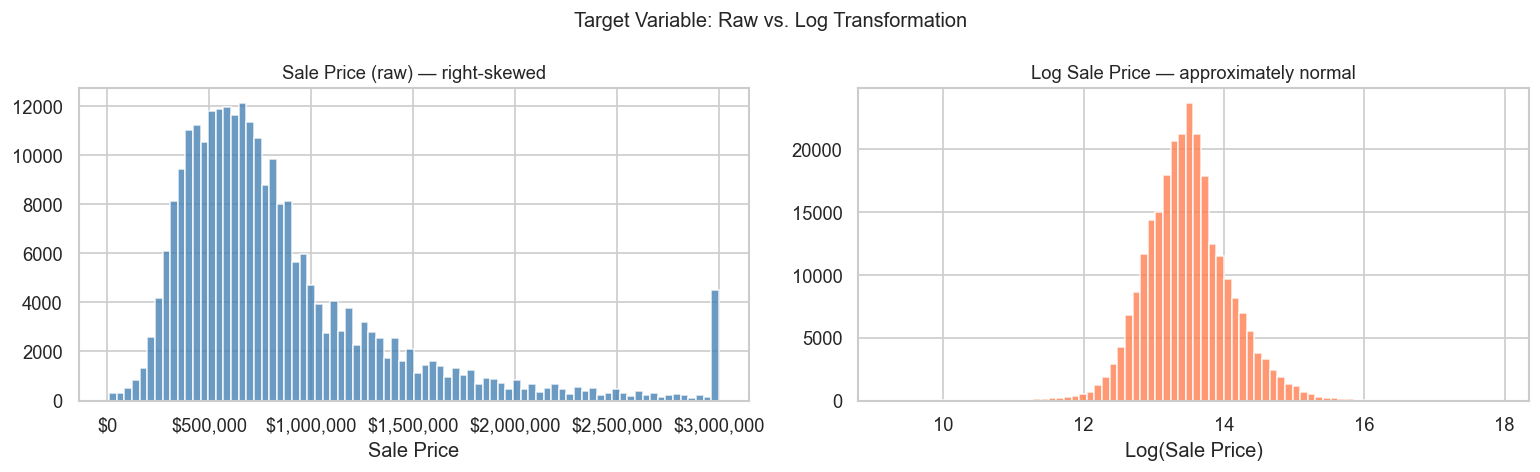

Sale price range: $10,091 – $60,000,000
Median: $700,000   Mean: $875,765


In [8]:
# ── Target variable distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(model_df['SalePrice'].clip(upper=3_000_000), bins=80,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].xaxis.set_major_formatter(fmt_dol)
axes[0].set_title('Sale Price (raw) — right-skewed', fontsize=11)
axes[0].set_xlabel('Sale Price')

axes[1].hist(model_df[TARGET], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Log Sale Price — approximately normal', fontsize=11)
axes[1].set_xlabel('Log(Sale Price)')

plt.suptitle('Target Variable: Raw vs. Log Transformation', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Sale price range: ${model_df["SalePrice"].min():,.0f} – ${model_df["SalePrice"].max():,.0f}')
print(f'Median: ${model_df["SalePrice"].median():,.0f}   Mean: ${model_df["SalePrice"].mean():,.0f}')

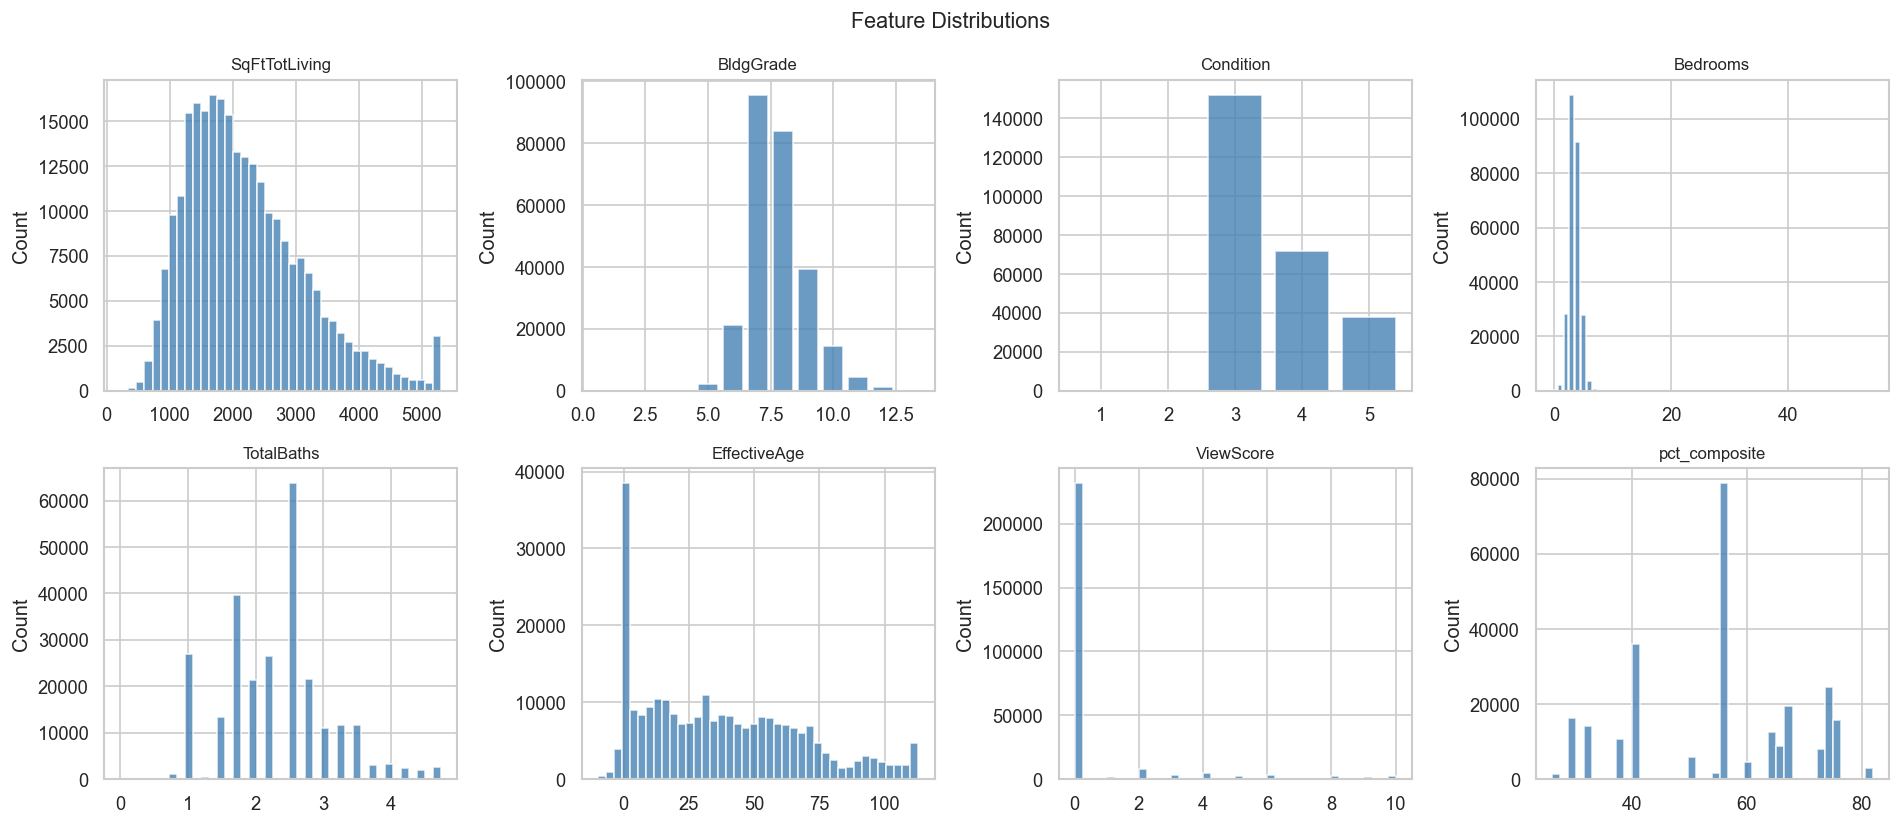

In [9]:
# ── Feature distributions overview ───────────────────────────────────────────
plot_features = ['SqFtTotLiving','BldgGrade','Condition','Bedrooms',
                 'TotalBaths','EffectiveAge','ViewScore','pct_composite']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), plot_features):
    data = model_df[col].dropna()
    if col in ['BldgGrade','Condition','Bedrooms']:
        vc = data.astype(int).value_counts().sort_index()
        ax.bar(vc.index, vc.values, color='steelblue', alpha=0.8)
    else:
        ax.hist(data.clip(upper=data.quantile(0.99)), bins=40,
                color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

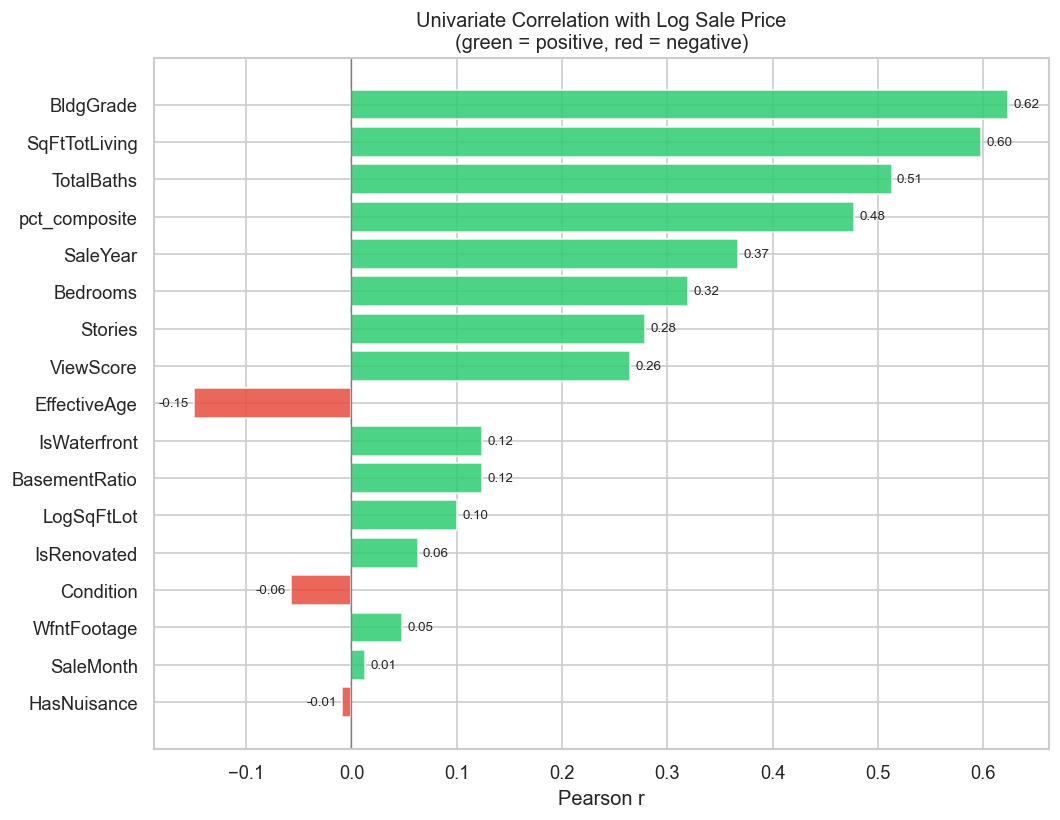

In [10]:
# ── Correlation with log price (univariate signal strength) ───────────────────
corr_features = [f for f in ALL_FEATURES if f != 'crime_count_500m']  # exclude sparse feature
corr = (
    model_df[corr_features + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='gray', lw=0.8)
for i, (feat, val) in enumerate(corr.items()):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_title('Univariate Correlation with Log Sale Price\n(green = positive, red = negative)',
             fontsize=12)
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

---
## 5. Missing Data Treatment

Two features have missing values. This section explains each case and the imputation strategy before any modeling begins.

---

### 5a — `crime_count_500m` (67.1% missing — 176,207 rows)

**Why it's missing:** Crime data was computed from Seattle Police Department incident records using a BallTree spatial join. Coverage is limited to properties within the Seattle city bounding box. Properties in suburban and rural King County (Bellevue, Redmond, Kirkland, Renton, Auburn, etc.) were never assigned a crime score — not because of a data error, but because no SPD data exists for those areas.

**Why fill with 0 (not drop, not impute from neighbors):**

| Option | Problem |
|--------|---------|
| Drop rows | Removes 67% of data; model becomes Seattle-only by construction, defeating the purpose of the KC-wide model |
| Impute with district median | Wrong signal — a Bellevue property should NOT inherit a Seattle neighborhood's crime count |
| Fill with 0 | Reflects reality: suburban King County genuinely has lower crime density. A count of 0 nearby serious crimes is a reasonable default for areas with no recorded SPD incidents |

**Additional safeguard:** Add a binary flag `has_crime_data` (1 = Seattle-area property with actual measurement, 0 = outside coverage). This lets the model learn the difference between "Seattle property with 0 crimes" and "suburban property with no data assigned."

**Important caveat (documented in model output):** In the Seattle-only model (Section 9), only rows with `has_crime_data = 1` are used, so the crime coefficient is estimated purely from real measurements with no imputed zeros contaminating it.

---

### 5b — `pct_composite` (0.5% missing — 1,228 rows)

**Why it's missing:** These properties could not be spatially matched to a school district in the GIS PIN-to-district lookup (likely parcels near district boundary edges or split-district cases).

**Strategy: impute with county-wide median**

At 0.5% of rows, the impact is negligible regardless of method. We use the county median (~55%) rather than dropping rows, because:
- Dropping would silently introduce a small bias (boundary properties skew toward certain areas)
- The median is the most defensible central estimate when district identity is unknown
- We do **not** use the mean because `pct_composite` is mildly left-skewed (a few low-performing districts pull it down)

In [11]:
# ── Missing data treatment ────────────────────────────────────────────────────

# 5a: crime_count_500m — flag then fill with 0
model_df['has_crime_data'] = model_df['crime_count_500m'].notna().astype(int)
model_df['crime_count_500m'] = model_df['crime_count_500m'].fillna(0)

# 5b: pct_composite — impute with county median
median_composite = model_df['pct_composite'].median()
model_df['pct_composite'] = model_df['pct_composite'].fillna(median_composite)

print('=== Missing data treatment complete ===')
print(f'  crime_count_500m: filled {(model_df["has_crime_data"]==0).sum():,} rows with 0')
print(f'    Seattle-area rows (has_crime_data=1): {model_df["has_crime_data"].sum():,}')
print(f'  pct_composite:    imputed with county median = {median_composite:.1f}%')
print(f'\nRemaining nulls in feature set:')
all_features_v2 = ALL_FEATURES + ['has_crime_data']
null_check = model_df[all_features_v2].isnull().sum()
print(null_check[null_check > 0].to_string() if null_check.any() else '  None — all features complete.')

=== Missing data treatment complete ===
  crime_count_500m: filled 176,207 rows with 0
    Seattle-area rows (has_crime_data=1): 86,540
  pct_composite:    imputed with county median = 56.6%

Remaining nulls in feature set:
  None — all features complete.


---
## 6. Train / Test Split

**Strategy: temporal split by `SaleYear`**

- Train: 2015–2021 (7 years, ~80% of data)
- Test: 2022–2024 (3 years, ~20% of data)

**Why temporal instead of random:**  
A random split would let the model "see" 2023 sales while training, then "predict" 2021 sales — leaking future market information backward. The temporal split simulates real deployment: train on historical data, predict unseen future sales. This gives a more honest estimate of out-of-sample error.

In [12]:
# ── Train / test split (temporal) ────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

FEATURES_FULL = FEATURES_STRUCTURAL + FEATURES_LOCATION + FEATURES_NEIGHBORHOOD + FEATURES_TEMPORAL + ['has_crime_data']

train_mask = model_df['SaleYear'] <= 2021
test_mask  = model_df['SaleYear'] >= 2022

X_train = model_df.loc[train_mask, FEATURES_FULL]
X_test  = model_df.loc[test_mask,  FEATURES_FULL]
y_train = model_df.loc[train_mask, TARGET]
y_test  = model_df.loc[test_mask,  TARGET]

print(f'Train (2015–2021): {len(X_train):,} rows')
print(f'Test  (2022–2024): {len(X_test):,} rows')
print(f'Features: {len(FEATURES_FULL)}')

Train (2015–2021): 201,933 rows
Test  (2022–2024): 60,814 rows
Features: 19


---
## 7. Model 1 — OLS Linear Regression (Baseline)

**Purpose:** Establish interpretable coefficients before adding model complexity.

The log-linear specification means each coefficient is a **semi-elasticity**: a one-unit increase in feature X → `exp(β) - 1` percent change in sale price. This lets us answer buyer questions directly:
- "A BldgGrade one step above Average adds X% to price, holding everything else constant"
- "Being in a district with a 10-point higher composite pass rate adds Y% to price"

OLS also validates that features are signed correctly before trusting the black-box model.

In [13]:
# ── Helper: evaluate model on test set ───────────────────────────────────────
def evaluate(name, y_true_log, y_pred_log):
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true_log, y_pred_log)
    mape   = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'  {name}')
    print(f'    R²   = {r2:.4f}')
    print(f'    RMSE = ${rmse:,.0f}')
    print(f'    MAE  = ${mae:,.0f}')
    print(f'    MdAPE= {mape:.1f}%')
    return {'model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MdAPE': mape}

# ── OLS baseline ──────────────────────────────────────────────────────────────
ols = LinearRegression()
ols.fit(X_train, y_train)
ols_pred = ols.predict(X_test)

print('=== Model 1: OLS Linear Regression ===')
results_ols = evaluate('OLS (Full KC)', y_test, ols_pred)

# Coefficient table — convert to % price effect
coef_df = (
    pd.DataFrame({'feature': FEATURES_FULL, 'coef': ols.coef_})
    .assign(pct_effect=lambda d: (np.exp(d['coef']) - 1) * 100)
    .sort_values('coef', key=abs, ascending=False)
)
print('\n--- OLS Coefficients (semi-elasticity: % price change per unit) ---')
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

=== Model 1: OLS Linear Regression ===
  OLS (Full KC)
    R²   = 0.6395
    RMSE = $551,287
    MAE  = $273,787
    MdAPE= 17.0%

--- OLS Coefficients (semi-elasticity: % price change per unit) ---
         feature    coef  pct_effect
    IsWaterfront  0.2461     27.9066
  has_crime_data  0.1904     20.9689
       BldgGrade  0.1785     19.5413
     IsRenovated  0.1465     15.7817
        SaleYear  0.0789      8.2051
      TotalBaths  0.0496      5.0833
       Condition  0.0306      3.1046
      LogSqFtLot -0.0227     -2.2473
       ViewScore  0.0212      2.1469
         Stories  0.0139      1.3968
   pct_composite  0.0120      1.2073
   BasementRatio  0.0107      1.0711
     HasNuisance -0.0095     -0.9502
       SaleMonth  0.0072      0.7183
        Bedrooms -0.0056     -0.5550
    EffectiveAge  0.0024      0.2384
     WfntFootage -0.0002     -0.0216
   SqFtTotLiving  0.0002      0.0170
crime_count_500m  0.0001      0.0124


---
## 8. Model 2 — XGBoost (Full KC)

**Why XGBoost over OLS:**  
Hedonic pricing relationships are not purely linear. For example:
- Adding a bedroom to a 1,000 sqft home has a different effect than adding one to a 4,000 sqft home
- BldgGrade interacts with SqFtTotLiving — a grade-10 finish on a small house adds less than the same finish on a large one
- Waterfront + view together may command a multiplicative premium, not purely additive

XGBoost (gradient boosted trees) handles these interactions automatically without manual feature crosses.

**Training setup:**  
- Same 2015–2021 training pool as OLS — no data withheld for the inner validation split  
- A random 10% of the training set is used as an early stopping validation set (prevents overfitting without shrinking the effective training window)  
- Main temporal boundary (train ≤ 2021 / test ≥ 2022) is what prevents temporal leakage — the inner random split does not introduce leakage

**Hyperparameters:** Light tuning only — `max_depth=6`, `learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8`. No full grid search (data is large enough that the default range is already well-behaved).

In [14]:
# ── XGBoost — Full KC ─────────────────────────────────────────────────────────
# Train on the full 2015-2021 dataset (same as OLS).
# Use a random 10% of the training set as early stopping validation —
# no need for a second temporal split here; the main temporal boundary
# (train ≤ 2021 / test ≥ 2022) already prevents leakage.
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

xgb_kc = xgb.XGBRegressor(
    n_estimators     = 1000,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    early_stopping_rounds = 30,
    eval_metric      = 'rmse',
    verbosity        = 0,
)
xgb_kc.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

xgb_kc_pred = xgb_kc.predict(X_test)
print('=== Model 2: XGBoost (Full KC) ===')
print(f'  Training rows: {len(X_tr):,}  |  Val rows: {len(X_val):,}  |  Test rows: {len(X_test):,}')
results_xgb_kc = evaluate('XGBoost (Full KC)', y_test, xgb_kc_pred)
print(f'  Best iteration: {xgb_kc.best_iteration}')

=== Model 2: XGBoost (Full KC) ===
  Training rows: 181,739  |  Val rows: 20,194  |  Test rows: 60,814
  XGBoost (Full KC)
    R²   = 0.6977
    RMSE = $482,589
    MAE  = $239,460
    MdAPE= 16.6%
  Best iteration: 996


---
## 9. Model 3 — XGBoost (Seattle-only, with Crime Score)

**Purpose:** Isolate the marginal effect of crime exposure on sale price, controlling for all structural and location features.

**Data scope:** Only rows where `has_crime_data = 1` (~86,500 sales in the Seattle bounding box). The imputed zeros are explicitly excluded — the crime coefficient is estimated from actual SPD measurements only.

**Comparison question:** How does `crime_count_500m` rank against school quality and structural features in terms of price impact within Seattle?

**Note:** Because this model is Seattle-only, the school quality coefficient will look different from the Full KC model — Seattle districts are clustered in a narrower score range compared to the full county spread. This is expected and documented in the comparison table.

In [15]:
# ── XGBoost — Seattle only (with actual crime counts) ─────────────────────────
sea_df = model_df[model_df['has_crime_data'] == 1].copy()

sea_train = sea_df[sea_df['SaleYear'] <= 2021]
sea_test  = sea_df[sea_df['SaleYear'] >= 2022]

X_sea_train = sea_train[FEATURES_FULL]
y_sea_train = sea_train[TARGET]
X_sea_test  = sea_test[FEATURES_FULL]
y_sea_test  = sea_test[TARGET]

X_sea_tr, X_sea_val, y_sea_tr, y_sea_val = train_test_split(
    X_sea_train, y_sea_train, test_size=0.1, random_state=42
)

xgb_sea = xgb.XGBRegressor(
    n_estimators     = 1000,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    early_stopping_rounds = 30,
    eval_metric      = 'rmse',
    verbosity        = 0,
)
xgb_sea.fit(X_sea_tr, y_sea_tr, eval_set=[(X_sea_val, y_sea_val)], verbose=False)

xgb_sea_pred = xgb_sea.predict(X_sea_test)
print('=== Model 3: XGBoost (Seattle-only) ===')
print(f'  Train rows: {len(X_sea_tr):,}  |  Val rows: {len(X_sea_val):,}  |  Test rows: {len(X_sea_test):,}')
results_xgb_sea = evaluate('XGBoost (Seattle-only)', y_sea_test, xgb_sea_pred)
print(f'  Best iteration: {xgb_sea.best_iteration}')

=== Model 3: XGBoost (Seattle-only) ===
  Train rows: 58,388  |  Val rows: 6,488  |  Test rows: 21,664
  XGBoost (Seattle-only)
    R²   = 0.6783
    RMSE = $527,265
    MAE  = $235,565
    MdAPE= 15.0%
  Best iteration: 557


---
## 10. Model Comparison & SHAP Interpretation

### 10a — Performance Summary
Side-by-side metrics for all three models.

### 10b — SHAP Feature Importance (XGBoost Full KC)
SHAP (SHapley Additive exPlanations) gives each feature a dollar-value contribution to every individual prediction, averaged across the test set. Unlike built-in XGBoost `feature_importances_`, SHAP accounts for feature interactions and shows directionality (not just magnitude).

We show:
1. **Beeswarm plot** — each dot is one test sale; color = feature value, x-position = SHAP value (impact on log price)
2. **Mean |SHAP| bar chart** — overall ranking of feature importance

### 10c — SHAP for School Quality & Crime (Key Buyer Questions)
Partial dependence plots for `pct_composite` and `crime_count_500m` — the two neighborhood quality features — holding all other features at their observed values. These directly answer:
- "How much is a 10-point better school district actually worth in dollars?"
- "What does a high-crime neighborhood cost buyers?"

In [16]:
# ── 10a: Performance comparison table ─────────────────────────────────────────
perf = pd.DataFrame([results_ols, results_xgb_kc, results_xgb_sea])
perf['RMSE'] = perf['RMSE'].apply(lambda x: f'${x:,.0f}')
perf['MAE']  = perf['MAE'].apply(lambda x:  f'${x:,.0f}')
perf['MdAPE']= perf['MdAPE'].apply(lambda x: f'{x:.1f}%')
perf['R2']   = perf['R2'].apply(lambda x: f'{x:.4f}')
print('=== Model Performance Summary ===')
print(perf.to_string(index=False))

=== Model Performance Summary ===
                 model     R2     RMSE      MAE MdAPE
         OLS (Full KC) 0.6395 $551,287 $273,787 17.0%
     XGBoost (Full KC) 0.6977 $482,589 $239,460 16.6%
XGBoost (Seattle-only) 0.6783 $527,265 $235,565 15.0%


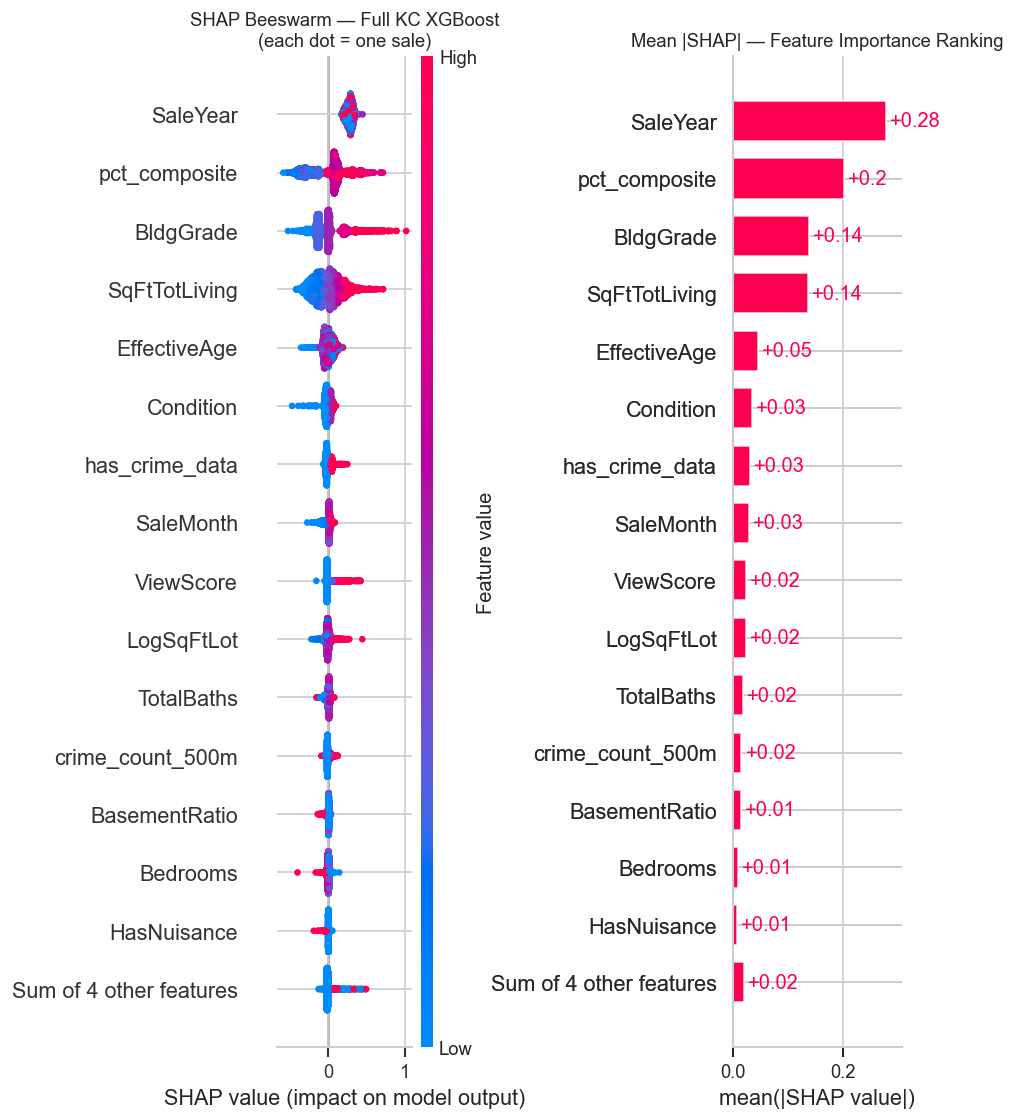

In [17]:
# ── 10b: SHAP beeswarm + bar (Full KC XGBoost) ────────────────────────────────
# Sample 5,000 test rows for speed
sample_idx = X_test.sample(5000, random_state=42).index
X_shap = X_test.loc[sample_idx]

explainer   = shap.TreeExplainer(xgb_kc)
shap_values = explainer(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.plots.beeswarm(shap_values, max_display=16, show=False)
axes[0].set_title('SHAP Beeswarm — Full KC XGBoost\n(each dot = one sale)', fontsize=11)

plt.sca(axes[1])
shap.plots.bar(shap_values, max_display=16, show=False)
axes[1].set_title('Mean |SHAP| — Feature Importance Ranking', fontsize=11)

plt.tight_layout()
plt.show()

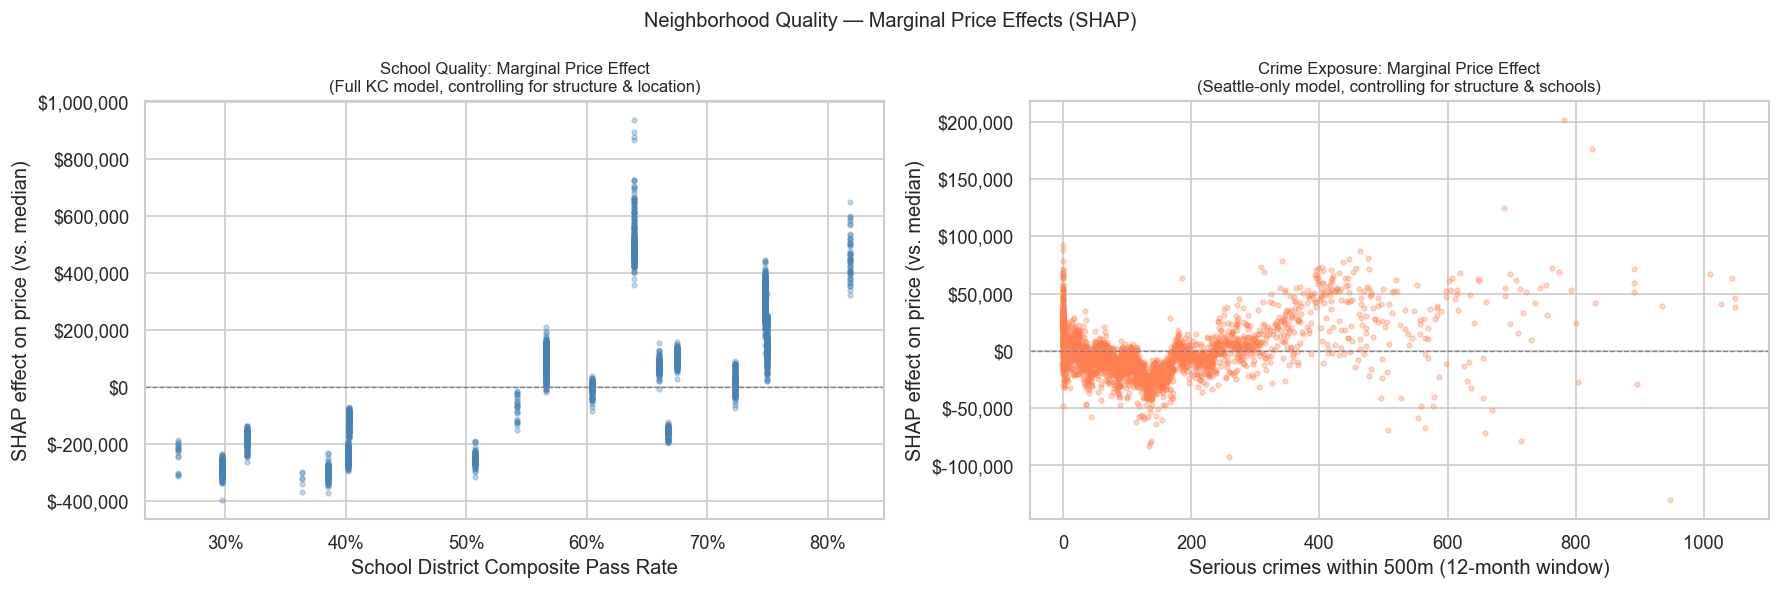

In [18]:
# ── 10c: School quality & crime — SHAP dependence plots ───────────────────────
median_price = model_df.loc[test_mask, 'SalePrice'].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# School quality (Full KC model)
feat_idx_school = list(FEATURES_FULL).index('pct_composite')
shap_school = shap_values[:, feat_idx_school].values
feat_school  = X_shap['pct_composite'].values
dollar_effect_school = (np.exp(shap_school) - 1) * median_price

axes[0].scatter(feat_school, dollar_effect_school, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[0].yaxis.set_major_formatter(fmt_dol)
axes[0].set_xlabel('School District Composite Pass Rate')
axes[0].set_ylabel('SHAP effect on price (vs. median)')
axes[0].set_title('School Quality: Marginal Price Effect\n(Full KC model, controlling for structure & location)', fontsize=10)

# Crime (Seattle-only model)
sample_sea_idx = X_sea_test.sample(min(3000, len(X_sea_test)), random_state=42).index
X_shap_sea    = X_sea_test.loc[sample_sea_idx]
explainer_sea = shap.TreeExplainer(xgb_sea)
shap_sea      = explainer_sea(X_shap_sea)

feat_idx_crime = list(FEATURES_FULL).index('crime_count_500m')
shap_crime  = shap_sea[:, feat_idx_crime].values
feat_crime  = X_shap_sea['crime_count_500m'].values
median_sea  = sea_df.loc[sea_df['SaleYear'] >= 2022, 'SalePrice'].median()
dollar_effect_crime = (np.exp(shap_crime) - 1) * median_sea

axes[1].scatter(feat_crime, dollar_effect_crime, alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].yaxis.set_major_formatter(fmt_dol)
axes[1].set_xlabel('Serious crimes within 500m (12-month window)')
axes[1].set_ylabel('SHAP effect on price (vs. median)')
axes[1].set_title('Crime Exposure: Marginal Price Effect\n(Seattle-only model, controlling for structure & schools)', fontsize=10)

plt.suptitle('Neighborhood Quality — Marginal Price Effects (SHAP)', fontsize=12)
plt.tight_layout()
plt.show()